## Assignment 2: Time Series Forecasting

### your name, your id, Version NN

#### Follow detail instructions in the assignment specification and use these heading for implementation and discussion

### 1. Paper evaluation

(Candanedo, LM, Feldheim, V & Deramaix, D 2017, 'Data driven prediction models of energy use of appliances in a low-energy house', Energy and buildings, vol. 140, pp. 81-97.)
https://myuni.adelaide.edu.au/courses/105130/files/16388685?wrap=1

In [1]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

### 2. Analyse and visualise the Time Series

In [2]:
data = pd.read_csv('energydata_complete.csv')
df = data.copy()
df = df[['Appliances', 'date']]
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)
df.head()

,Appliances
date,
2016-02-14 00:00:00,50
2016-02-14 00:10:00,50
2016-02-14 00:20:00,60
2016-02-14 00:30:00,40
2016-02-14 00:40:00,60


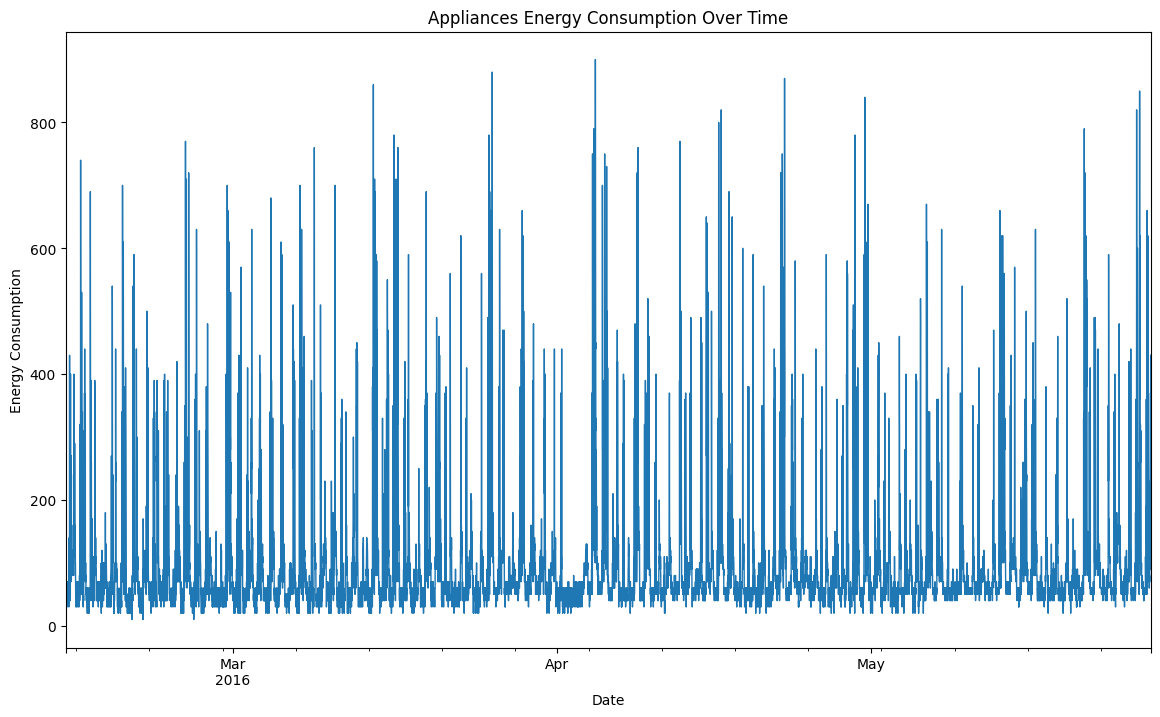

In [3]:
df['Appliances'].plot(figsize=(14, 8), title='Appliances Energy Consumption Over Time', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.show()

As can be seen above, the time series does not yield any obvious trend on energy usage (Appliances) overtime. However, the absence of pattern does not necessarily imply that the data is stable. For further stationary checking, let's plot the simple moving average

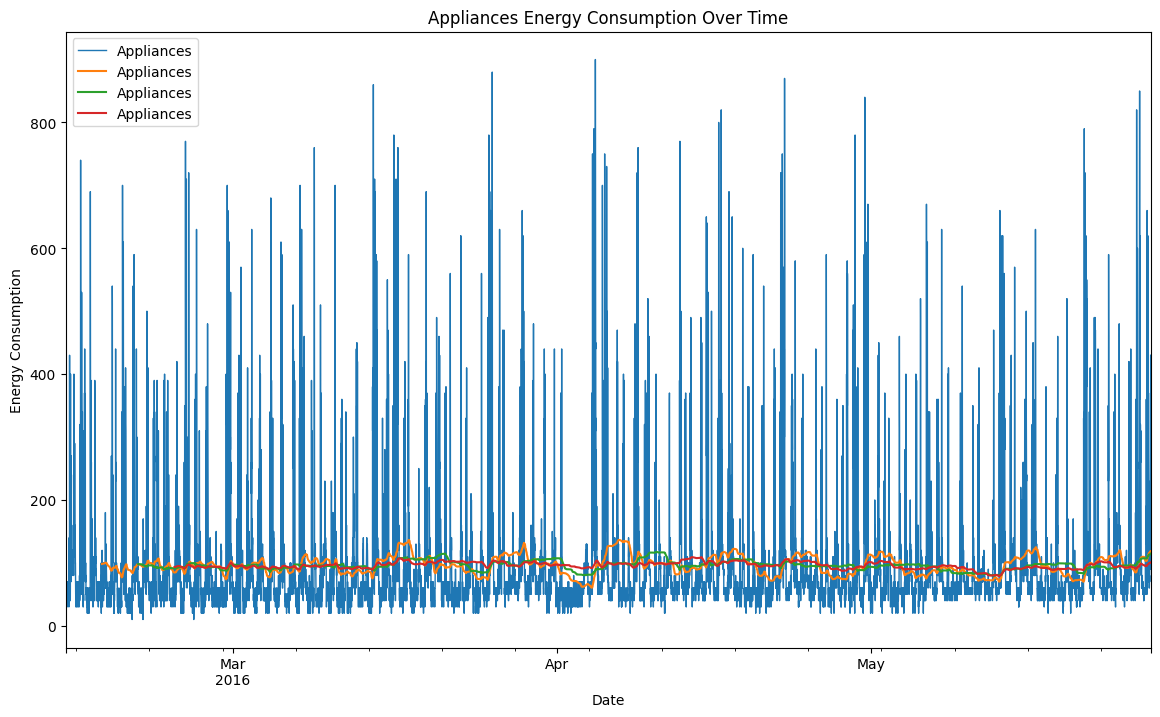

In [4]:
df_sma_500 = df['Appliances'].rolling(window=500).mean()
df_sma_1000 = df['Appliances'].rolling(window=1000).mean()
df_sma_1500 = df['Appliances'].rolling(window=1500).mean()

df['Appliances'].plot(figsize=(14, 8), title='Appliances Energy Consumption Over Time', linewidth=1)
df_sma_500.plot()
df_sma_1000.plot()
df_sma_1500.plot()
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.legend()
plt.show()

Even with averaging, the series is still stable, suggesting the series may already be stationary

### 3. Pre-process the data

In [5]:
#Spliting
train_dev_size = int(len(df) * 0.75)

df_train_dev = df.iloc[:train_dev_size] 
df_test = df.iloc[train_dev_size:]

print(f"df_train_dev shape: {df_train_dev.shape}")
print(f"df_test shape: {df_test.shape}")

df_train_dev shape: (11205, 1)
df_test shape: (3736, 1)


### 4. Model training and selection

In [8]:
# Time series techniques (cite Module 5 Online learning/chapter 12)
# 1. Decomposition
# 2. Smoothing based techniques
# 3. Regression based techniques
# 4. machine learning-based techniques

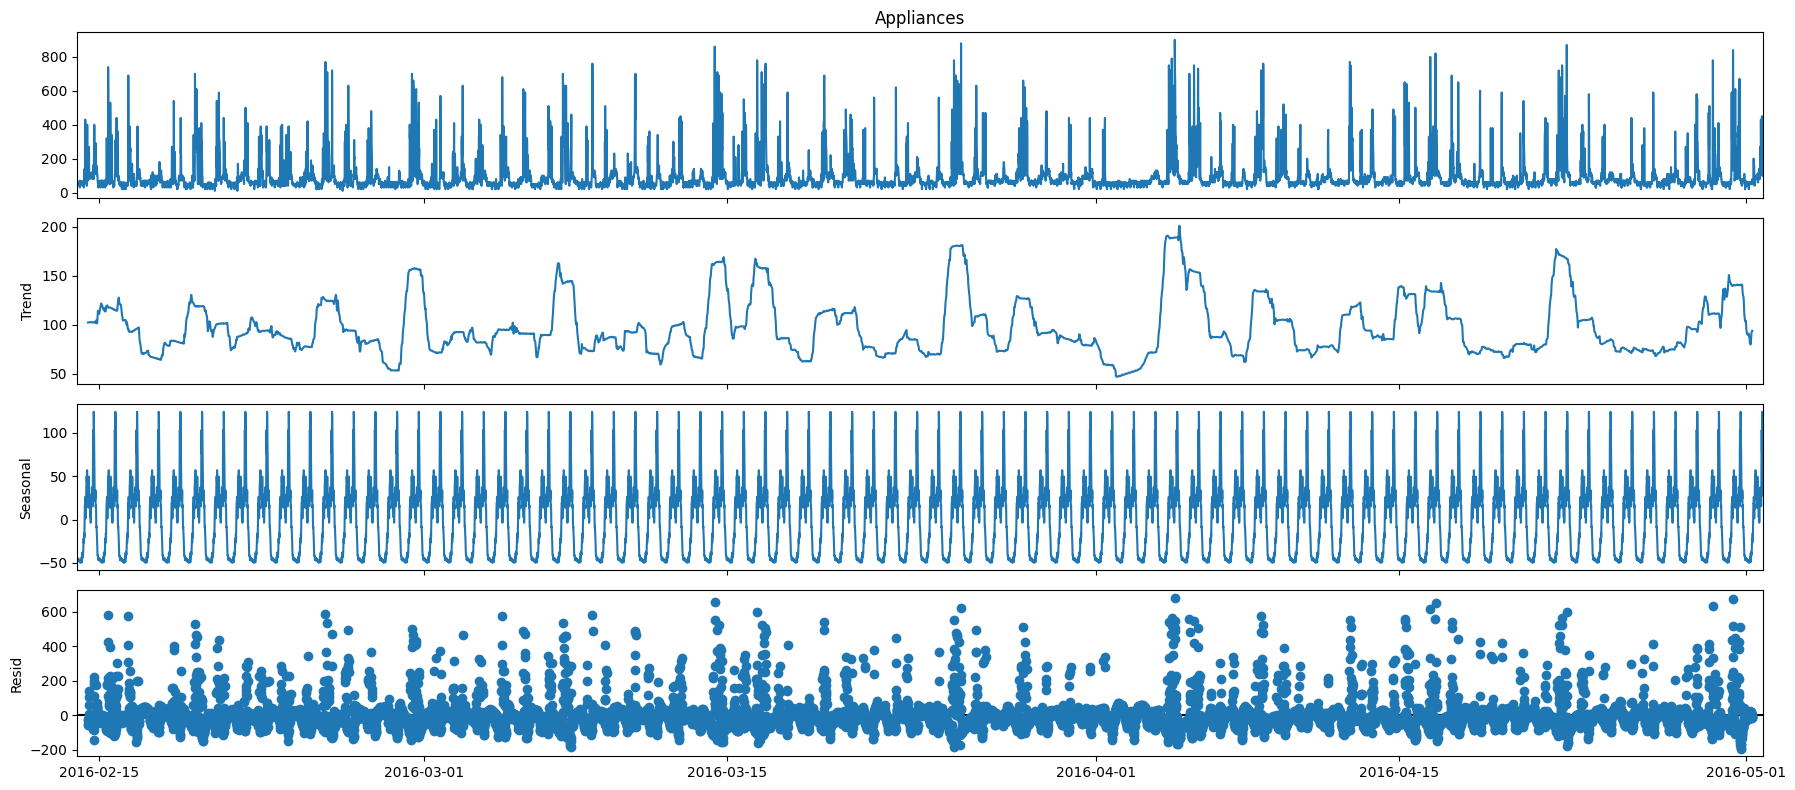

In [8]:
# Decomposition

rcParams['figure.figsize'] = 18, 8

decomposition = seasonal_decompose(df_train_dev['Appliances'], model='additive', period=144) #24*60/10=144 Daily data
decomposition.plot()
plt.show()

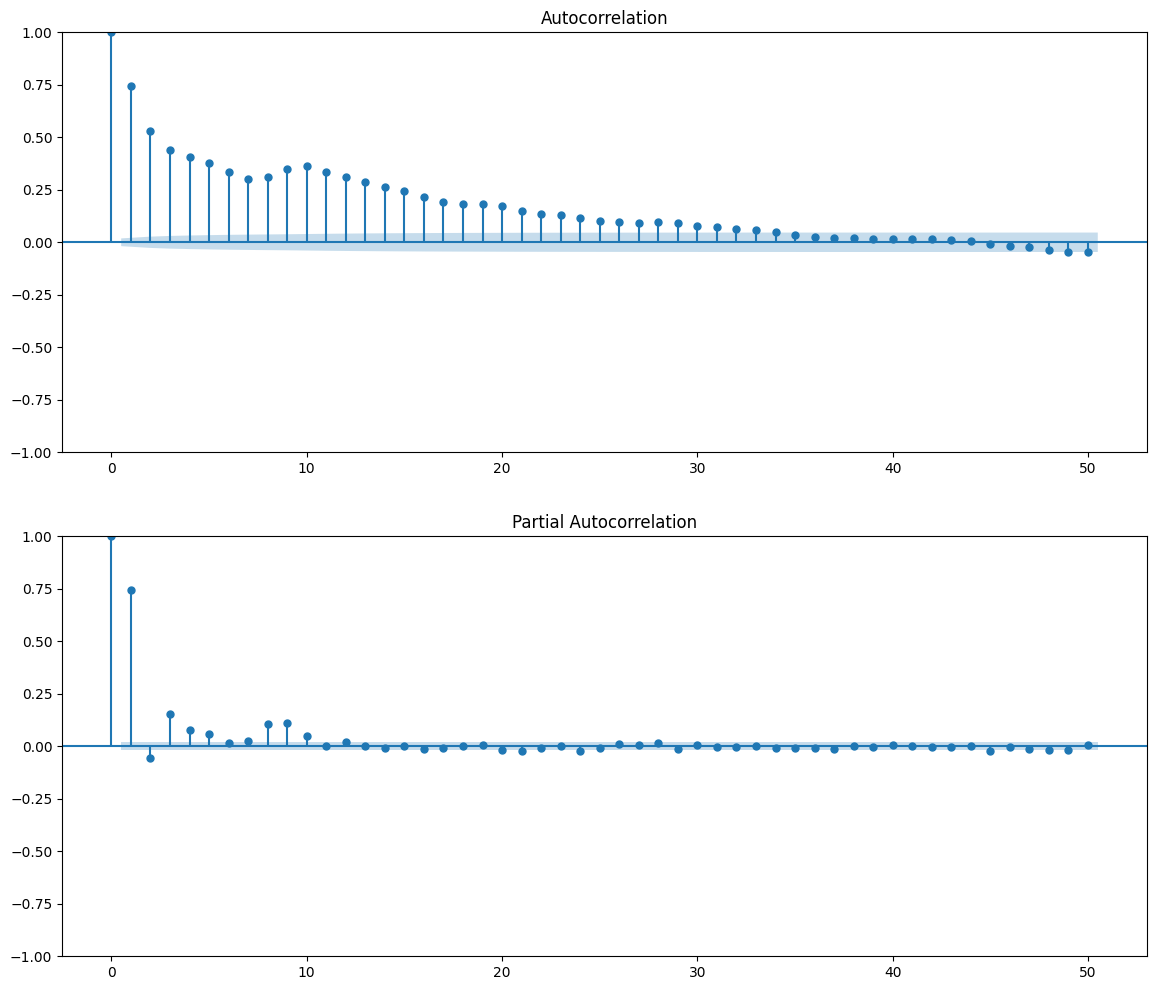

In [10]:
# As dicussed before, the time series is stationary, so we will choose d = 0 for the ARIMA model
# We will use the ACF and PACF plots to determine the values of p and q

# Finding p and q 

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(14, 12))

plot_acf(df_train_dev['Appliances'], lags=50, ax=ax[0])
plot_pacf(df_train_dev['Appliances'], lags=50, ax=ax[1])
plt.show()


p = q = 3

                               SARIMAX Results                                
Dep. Variable:             Appliances   No. Observations:                11205
Model:                 ARIMA(3, 1, 3)   Log Likelihood              -62864.498
Date:                Mon, 10 Mar 2025   AIC                         125742.996
Time:                        22:18:44   BIC                         125794.264
Sample:                    02-14-2016   HQIC                        125760.252
                         - 05-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1416      0.541     -0.262      0.793      -1.202       0.918
ar.L2          0.1658      0.215      0.770      0.441      -0.256       0.588
ar.L3          0.0378      0.027      1.398      0.1

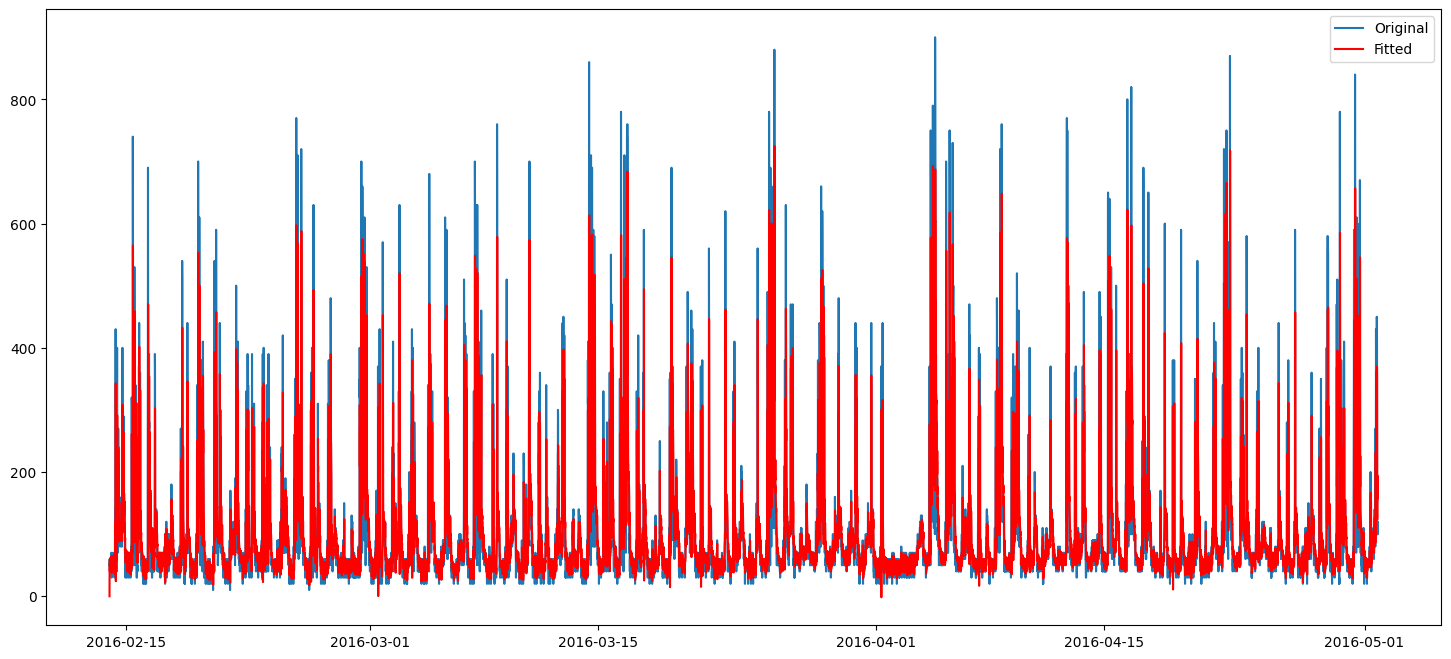

In [30]:
import statsmodels.api as sm

model_arima = sm.tsa.arima.ARIMA(df_train_dev['Appliances'], order=(3,1,3))
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())
plt.plot(df_train_dev['Appliances'], label='Original')
plt.plot(model_arima_fit.fittedvalues, color='red', label='Fitted')
plt.legend()
plt.show()

Root Mean Squared Error: 131.13030581837162
Mean Absolute Error: 122.801988838635


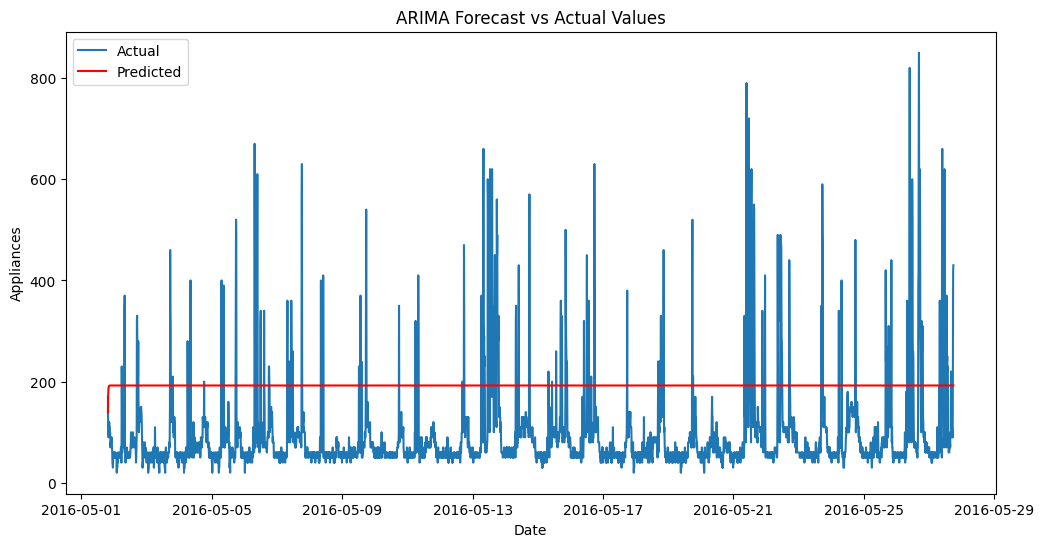

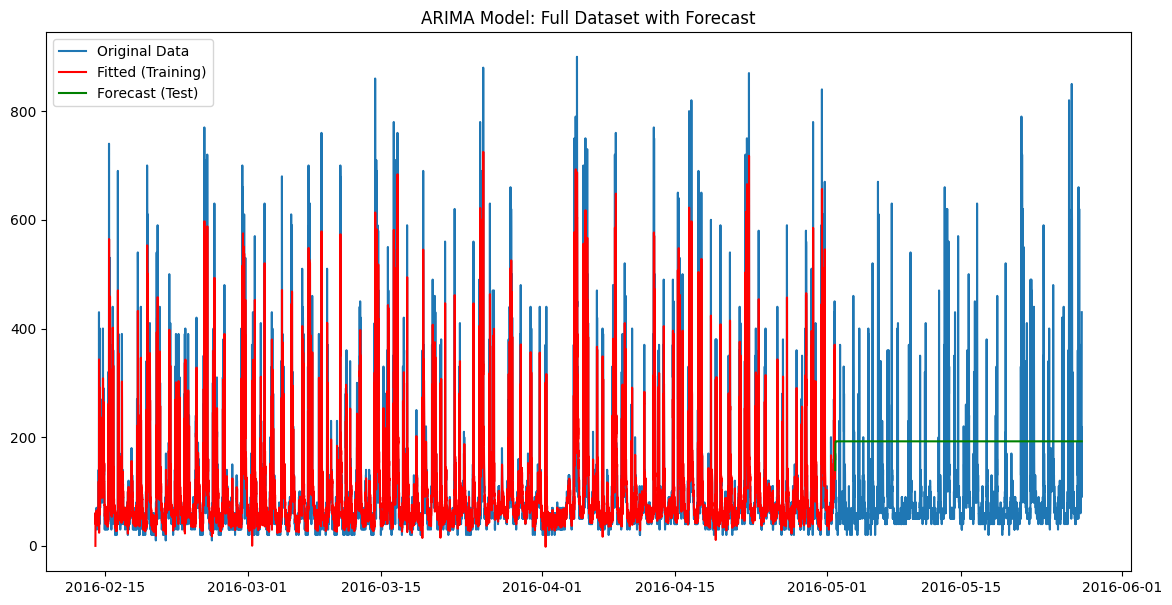

In [31]:
# Predict on the test set
forecast = model_arima_fit.forecast(steps=len(df_test))

# Create a DataFrame to compare actual vs predicted
comparison_df = pd.DataFrame({
    'Actual': df_test['Appliances'].values,
    'Predicted': forecast
})

# Calculate error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(comparison_df['Actual'], comparison_df['Predicted']))
mae = mean_absolute_error(comparison_df['Actual'], comparison_df['Predicted'])

print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")

# Plot the comparison
plt.figure(figsize=(12, 6))
plt.plot(df_test.index, comparison_df['Actual'], label='Actual')
plt.plot(df_test.index, comparison_df['Predicted'], color='red', label='Predicted')
plt.title('ARIMA Forecast vs Actual Values')
plt.xlabel('Date')
plt.ylabel('Appliances')
plt.legend()
plt.show()

# Plot the forecast against the entire dataset to see the bigger picture
plt.figure(figsize=(14, 7))
plt.plot(df['Appliances'], label='Original Data')
plt.plot(df_train_dev.index, model_arima_fit.fittedvalues, color='red', label='Fitted (Training)')
plt.plot(df_test.index, forecast, color='green', label='Forecast (Test)')
plt.title('ARIMA Model: Full Dataset with Forecast')
plt.legend()
plt.show()

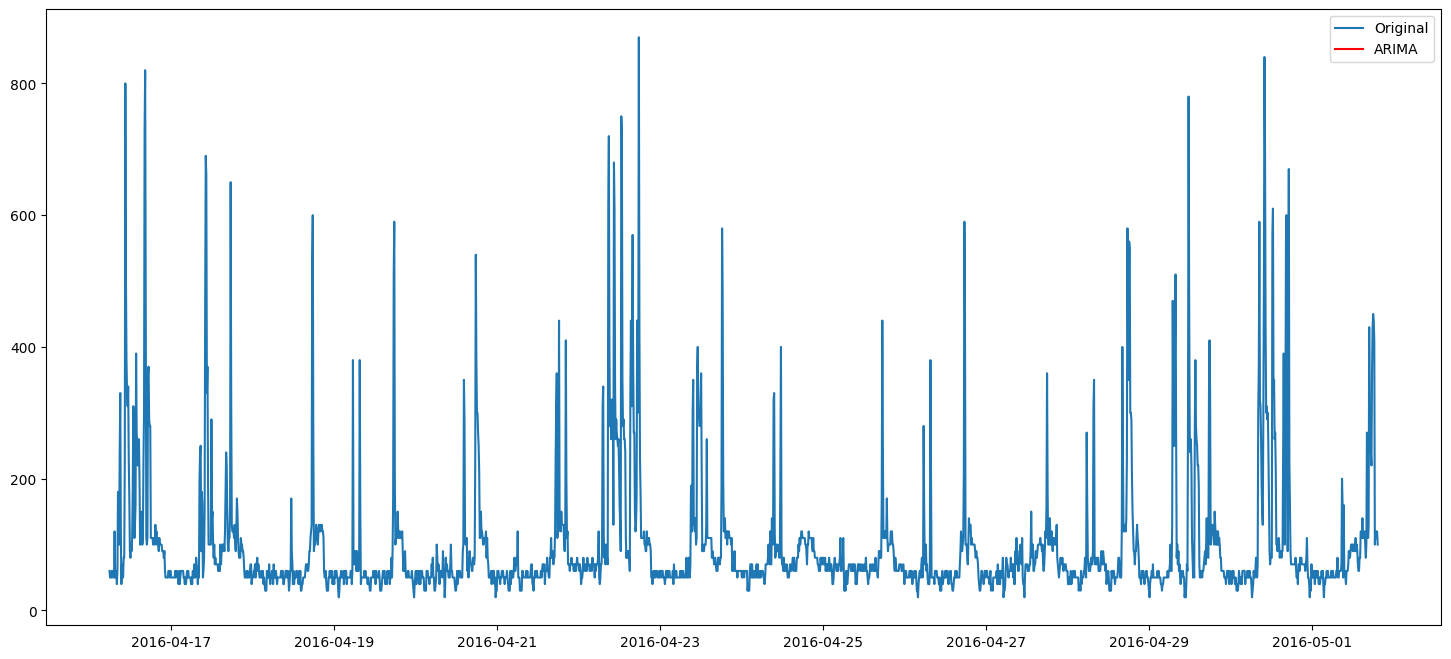

In [88]:
# add back trend and seasonal components
arima_predictions = arima_predictions + trend + seasonal

plt.plot(df_dev['Appliances'], label='Original')
plt.plot(arima_predictions, color='red', label='ARIMA')
plt.legend()
plt.show()

### 5. Testing and analysis of the final model


### 6. Reflection

### 7. References

### 8. Appendix